<a href="https://colab.research.google.com/github/tomasrodriguezr11/Programacion-MIAAD/blob/main/EjercicioSemana9_266228.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejercicio: Práctica de Generalización, Overfitting y Underfitting**
**Programación para analítica descriptiva y predictiva MIAAD**

*Realizada por: Tomás Eduardo Rodríguez Ramírez*

*Número de matrícula: 266228*

Tomando como ejemplo el cuaderno que se compartió en los recursos. Realiza ahora los siguientes ejercicios:

1. Cambia los parámetros del conjunto de datos moon, en específico el ruido del dataset a noise =0.05
2. Al igual que en cuaderno de práctica, dibuja las curvas de complejidad usando max_depth de 1 a 20
3. En qué valores de max_depth se observa un overfitting y un underfitting
4. Cambia los parámetros del conjunto de datos moon, en específico el ruido del dataset a noise =0.40
5. Al igual que en cuaderno de práctica, dibuja las curvas de complejidad usando max_depth de 1 a 20
6. En qué valores de max_depth se observa un overfitting y un underfitting

Sube el link de tu cuaderno en Google Colab o github. Verifica que esté ejecutado el cuaderno.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np
# Loss 0-1 = 1 - accuracy
def loss_01(y_true, y_pred):
    """Fraccion de ejemplos mal clasificados."""
    return 1.0 - accuracy_score(y_true, y_pred)

print('Listo.')

Listo.


# **Ejercicio 1. Ruido del data set = 0.05**

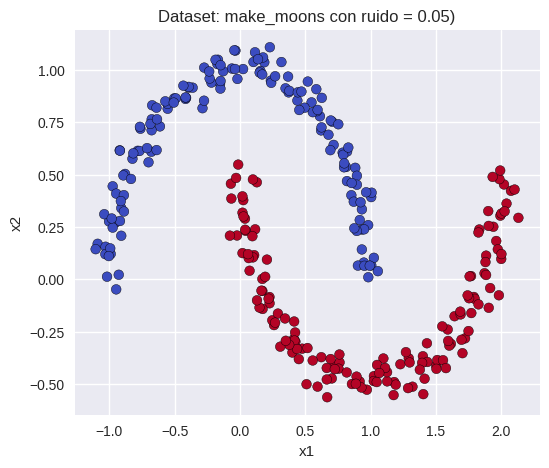

In [25]:
# Generamos el dataset
np.random.seed(42)

#X tiene el conjunto de datos de M x N
#Y es el vector de clases
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

# Visualizamos el dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", edgecolor="k")
plt.title("Dataset: make_moons con ruido = 0.05)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [26]:
# Split 70 / 30
# 70% datos de Entrenamiento
# 30% Datos de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

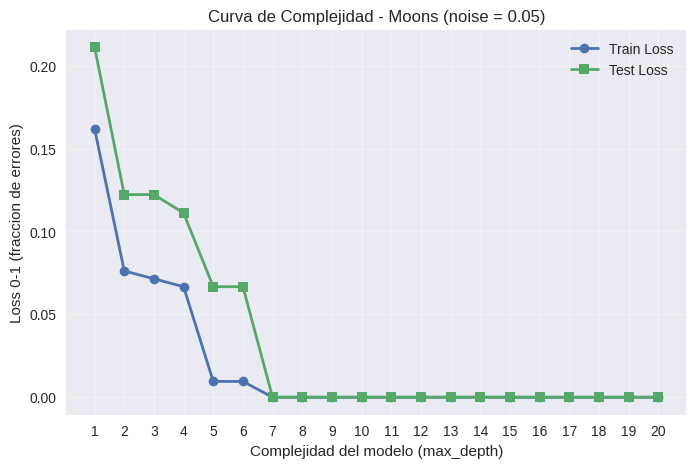

In [27]:
# Curva de complejidad
#Aquí se define una lista de parámetros a usar en Decision Tree
depths = range(1,21)

train_loss = []
test_loss = []

#En este ciclo se entrenan y evalúan los modelos de decisión con tree
for d in depths:

    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_loss.append(loss_01(y_train, y_pred_train))
    test_loss.append(loss_01(y_test, y_pred_test))


plt.style.use("seaborn-v0_8")

plt.figure(figsize=(8,5))

plt.plot(depths, train_loss,
         marker='o',
         linewidth=2,
         label="Train Loss")

plt.plot(depths, test_loss,
         marker='s',
         linewidth=2,
         label="Test Loss")

plt.xticks(depths)
plt.xlabel("Complejidad del modelo (max_depth)")
plt.ylabel("Loss 0-1 (fraccion de errores)")
plt.title("Curva de Complejidad - Moons (noise = 0.05)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### **Interpretación**

- Para valores pequeños de max_depth (1 y 2) se observa underfitting, ya que el modelo es demasiado simple para capturar la estructura no lineal del dataset.

- El mejor desempeño se encuentra aproximadamente entre max_depth = 3 y 5, donde la pérdida de entrenamiento y prueba son bajas y similares.

- A partir de valores cercanos a max_depth ≥ 6 o 7 comienza a observarse overfitting, ya que la pérdida de entrenamiento se aproxima a cero mientras que la pérdida de prueba deja de mejorar.

# **Ejercicio 2. Ruido del data set = 0.4**

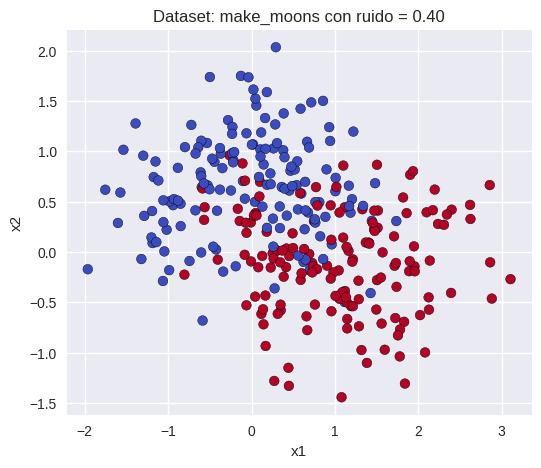

In [28]:
# Generamos el dataset
np.random.seed(42)

#X tiene el conjunto de datos de M x N
#Y es el vector de clases
X, y = make_moons(n_samples=300, noise=0.40, random_state=42)

# Visualizamos el dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", edgecolor="k")
plt.title("Dataset: make_moons con ruido = 0.40")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [29]:
# Split 70 / 30
# 70% datos de Entrenamiento
# 30% Datos de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

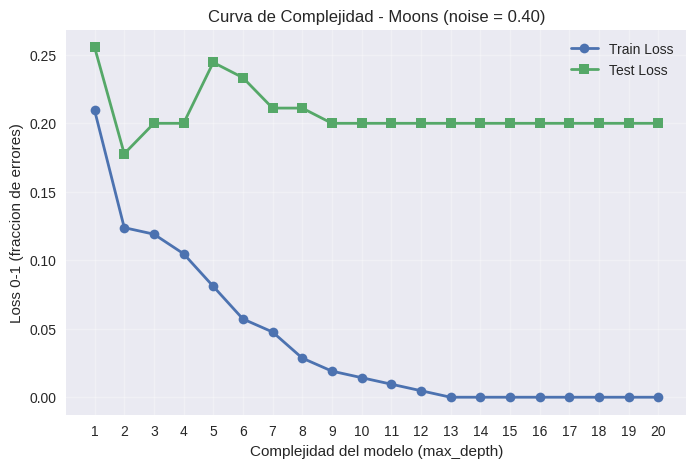

In [30]:
# Curva de complejidad
#Aquí se defineb una lista de parámetros a usar en Decision Tree
depths = range(1,21)

train_loss = []
test_loss = []

#En este ciclo se entrenan y evalúan los modelos de decisión con tree
for d in depths:

    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_loss.append(loss_01(y_train, y_pred_train))
    test_loss.append(loss_01(y_test, y_pred_test))


plt.style.use("seaborn-v0_8")

plt.figure(figsize=(8,5))

plt.plot(depths, train_loss,
         marker='o',
         linewidth=2,
         label="Train Loss")

plt.plot(depths, test_loss,
         marker='s',
         linewidth=2,
         label="Test Loss")

plt.xticks(depths)
plt.xlabel("Complejidad del modelo (max_depth)")
plt.ylabel("Loss 0-1 (fraccion de errores)")
plt.title("Curva de Complejidad - Moons (noise = 0.40)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### **Interpretación**

- Se observa underfitting aproximadamente entre max_depth = 1 y 4, debido a que el alto nivel de ruido dificulta que modelos simples capturen la estructura del dataset.

- El mejor desempeño se encuentra aproximadamente entre max_depth = 5 y 8.

- El overfitting comienza a observarse claramente para valores de max_depth ≥ 9 o 10, donde el modelo empieza a ajustarse al ruido presente en los datos, disminuyendo la pérdida de entrenamiento pero aumentando la pérdida de prueba.